# Vanilla Optimisation (PyFMI)

Perform vanilla optimisation by minimising sum of squared errors. Perform this multiple times with different initialisations of starting values.

In [4]:
import warnings
import numpy as np
from pyfmi import load_fmu


# Define model options
model = load_fmu("cstr_model.fmu")
opts = model.simulate_options()
opts["result_handling"] = "memory"
opts["CVode_options"]["verbosity"] = 50
opts['CVode_options']['maxh']=0.01


# Define simulator wrapper
def simulator(params):

    Ci, Ti, Tci, Qc = [0.97, 351.5, 351.6, 150]
    UA, k_0 = params
    y0 = np.array([0.1,430,416])
    model.reset()

    start_values={'UA':UA,'k_0':k_0,'Ci':Ci,'Ti':Ti,'Tci':Tci,'Qc':Qc}
    
    for item in start_values:
        model.set(item, start_values[item])

    result = model.simulate(start_time=0, final_time=20,options=opts)

    output = np.array([result['C'][-1], result['T'][-1], result['Tc'][-1]])
    output_5 = np.array([result['C'][-5], result['T'][-5], result['Tc'][-5]])

    # Check tolerance 
    abs_error = abs(output - output_5)
    rel_error = abs_error*100/y0
    error_percentage = 1

    # If simulation is outside of local tolerance, then issue warning and return array of null values
    if any(rel_error>error_percentage):
        warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
        raise RuntimeError("Not converged; don't count")

    return output

    

In [3]:
# Check if it works by running a simulation
true_params = [7E5, 7.2E10]
observation = simulator(true_params)
observation

array([1.07831731e-01, 4.28696634e+02, 4.15091346e+02])

In [97]:
from time import time

# Summary stat
def summary_stat(y_pred, y_true):
    return np.sum((y_pred-y_true)**2)


# Objective function
def objective_function(params):

    # Using these values for scaling
    y0 = np.array([0.1,430,416])
    
    # In case we get errors, return nan
    try:
        y_pred = simulator([params[0]*1E5, params[1]*1E10])    
        res = summary_stat(y_pred/y0, observation/y0)
    
        return res
    except:
        return np.nan
    

from scipy.optimize import minimize

# Perform optimisation several times with different starting values
store=[]
start_time = time()
for it in range(1000):
    print(it)
    param_0 = [np.random.rand(1)*10,np.random.rand(1)*10]
    res = minimize(objective_function,param_0,bounds=((6,10),(1,10)),)
    if res.success:
        #print(param_0)
        #print(res.x)
        
        store.append(res.x)
        
print(f'Time taken is {(time()-start_time)/60} minutes')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.14846262 0.04452529 0.03695201]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.14846266 0.04452529 0.03695201]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.14846252 0.04452528 0.036952  ]


20
21
22
23
24
25
26
27
28
29
30
31


/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.01722402e+00 2.23688636e-04 2.36350558e-03]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.01722453e+00 2.23706106e-04 2.36352024e-03]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.01722259e+00 2.23638431e-04 2.36346350e-03]


32
33
34


...

977
978
979
980
981
982
983
984
985


/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.53568364 0.06967831 0.05804846]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.53568363 0.06967831 0.05804847]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.53568368 0.0696783  0.05804846]


986
987


/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.99826978 0.08594086 0.07310536]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.9982698  0.08594087 0.07310536]
/home/keepfloyding/miniconda3/envs/py-36/lib/python3.6/site-packages/ipykernel_launcher.py:38: RuntimeWarning: Solution not converged. [1.99826974 0.08594086 0.07310535]


988
989
990
991
992
993
994
995
996
997
998
999
Time taken is 30.01610428094864 minutes


(6.0, 8.0)

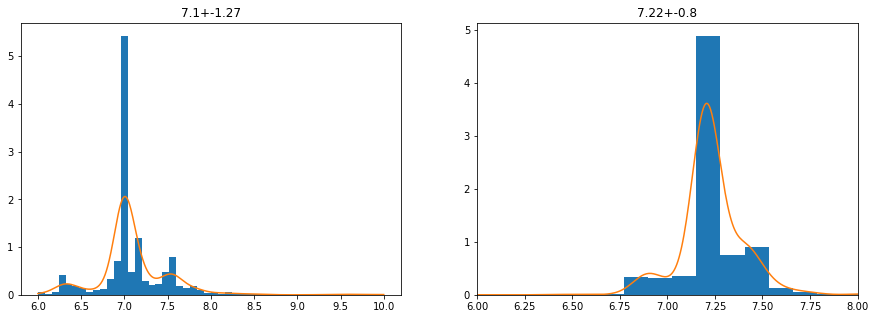

In [104]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

plt.subplots(1,2,figsize=(15,5))

# Pot histogram of parameter 1
plt.subplot(1,2,1)
x = [item[0] for item in store]
xx = np.linspace(min(x), max(x), 1000)

plt.hist(x,bins=50,density=True);
plt.title(str(round(np.mean(x),2))+'+-'+str(round(3*np.std(x),2)))

kde = stats.gaussian_kde(x)
plt.plot(xx, kde(xx))

# Pot histogram of parameter 2
plt.subplot(1,2,2)
x = [item[1] for item in store]
xx = np.linspace(min(x), max(x), 1000)
plt.hist(x,bins=50,density=True);
plt.title(str(round(np.mean(x),2))+'+-'+str(round(3*np.std(x),2)))
kde = stats.gaussian_kde(x)
plt.plot(xx, kde(xx))
plt.xlim([6,8])


(6.0, 8.488344461458327)

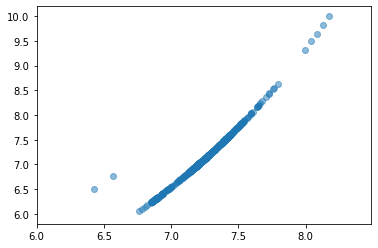

In [99]:
# Scatter plot to see dependance between parameter 1 and parameter 2

x = [item[1] for item in store]
y = [item[0] for item in store]

plt.scatter(x,y,alpha=0.5)
plt.xlim(6,None)